In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import geopandas as gpd
import json
import unicodedata
import plotly.graph_objects as go
import scipy.stats as stats
import dash
from dash import dcc, html, Input, Output

/Users/santiagoquintana/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
Data = pd.read_csv('../DataAWS.csv')

cols_used = ['fami_educacionmadre', 'fami_educacionpadre', #heatmap
             'cole_area_ubicacion', 'cole_caracter','cole_naturaleza','cole_jornada', #barplots apilados y donas y geograficos
             'cole_mcpio_ubicacion', 'cole_nombre_establecimiento',             
             'punt_matematicas','punt_c_naturales'] # histograma kde
Data_used = Data[cols_used].dropna(subset=cols_used)
Data_used['punt_prom_mcn'] = Data_used[['punt_matematicas','punt_c_naturales']].mean(axis=1) # limpieza provisional eliminar filas nan masivamente

In [6]:
[i.lower() for i in list(Data_used.cole_caracter.unique())]

['técnico/académico', 'técnico', 'académico', 'no aplica']

In [27]:
mapeo_educativo = {'Educación profesional completa': 4,
 'Educación profesional incompleta': 3.5,
 'Ninguno': 0,
 'No Aplica': 0,
 'No sabe': 0,
 'Postgrado': 5,
 'Primaria completa': 1,
 'Primaria incompleta': 0.5,
 'Secundaria (Bachillerato) completa': 2,
 'Secundaria (Bachillerato) incompleta': 1.5,
 'Técnica o tecnológica completa': 3,
 'Técnica o tecnológica incompleta': 2.5
 }
# proemdio padre - madre mapeado

In [28]:
with open('../gadm41_COL_2.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)
    
with open('../gadm41_COL_1.json', 'r', encoding='utf-8') as f:
    geojson_dpto = json.load(f)

def normalizar(name):
    name = name.lower().strip()
    name = unicodedata.normalize('NFKD', name)
    name = ''.join(c for c in name if not unicodedata.combining(c))
    name = name.replace(' ', '')
    name = name.replace('cienega', 'cienaga')
    name = name.replace('guicandelasierra', 'guican')
    name = name.replace('pisva', 'pisba')
    name = name.replace('tutasa', 'tutaza')
    return name

boyaca_dpto = next(f for f in geojson_dpto['features'] if normalizar(f['properties']['NAME_1']) == 'boyaca') #sacar datos geo del depto
            
todos_municipios = Data_used['cole_mcpio_ubicacion'].dropna().unique().tolist()

#mapeo nombres municipios
mapa_norm_a_real = {}
for m in todos_municipios:
    norm = normalizar(m)
    if norm not in mapa_norm_a_real:
        mapa_norm_a_real[norm] = m
    else:
        existente = mapa_norm_a_real[norm]
        count_nuevo    = len(Data_used[Data_used['cole_mcpio_ubicacion'] == m])
        count_existente = len(Data_used[Data_used['cole_mcpio_ubicacion'] == existente])
        if count_nuevo > count_existente:
            mapa_norm_a_real[norm] = m


#lista de datos geo que coinciden con los municipios del dataset
geos_coinc = []
for feature in geojson_data['features'][212:335]:
    nombre_municipio = feature['properties']['NAME_2']
    if normalizar(nombre_municipio) in mapa_norm_a_real:
        geos_coinc.append(feature)

# geojson filtrado con municipios q coinciden en ambos
filt_geojson = {"type": "FeatureCollection", "features": geos_coinc}
for i, feature in enumerate(filt_geojson['features']):
    feature['id'] = i

# mapeo de indice, nombre y nombre real 
plot_df = pd.DataFrame([
    {   "id": i,
        "name": f['properties']['NAME_2'],
        "nombre_real": mapa_norm_a_real.get(normalizar(f['properties']['NAME_2']))} for i, f in enumerate(filt_geojson['features'])
])

# sacar bordes de depto de boyaca (geo data)
latids_bordes, longs_bordes = [], []
geom = boyaca_dpto['geometry']
polys = geom['coordinates'] if geom['type'] == 'Polygon' else geom['coordinates']
for poly in polys:
    ring = poly[0]
    longs_bordes.extend([p[0] for p in ring] + [None])
    latids_bordes.extend([p[1] for p in ring] + [None])

In [ ]:
mapa_norm_a_real = {}
for m in sorted(Data_used['cole_mcpio_ubicacion'].dropna().unique()):
    norm = normalizar(m)
    if norm not in mapa_norm_a_real:
        mapa_norm_a_real[norm] = m

plot_df['nombre_real'] = plot_df['name'].apply(
    lambda x: mapa_norm_a_real.get(normalizar(x))
)

### crear histograma con KED-boyaca por municpio segun variable de colegio

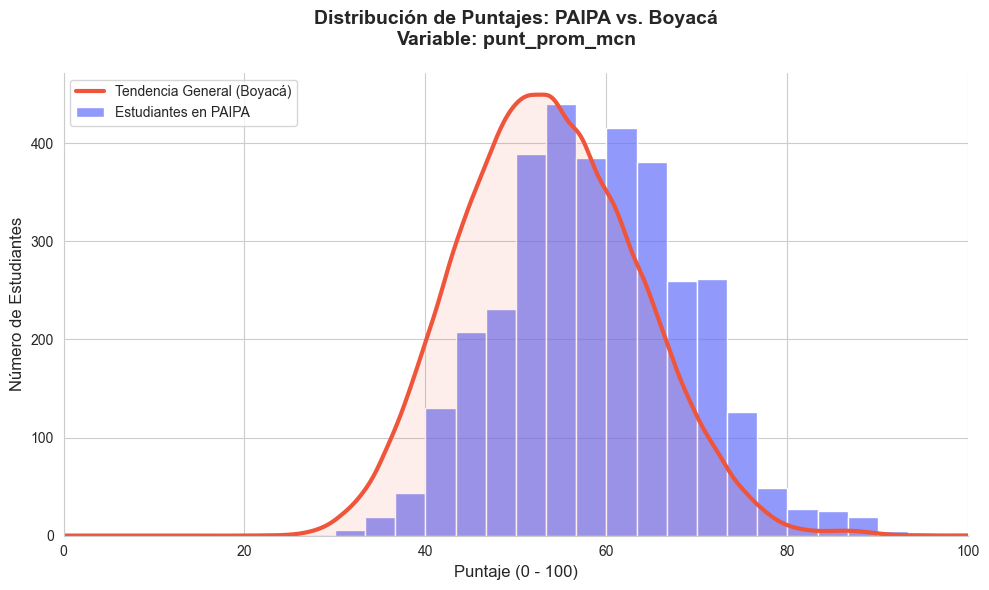

In [33]:
MUNICIPIO = 'PAIPA'
VARIABLE = 'punt_prom_mcn'

data_mcpio = Data_used[Data_used['cole_mcpio_ubicacion'] == MUNICIPIO][VARIABLE]
data_boyaca = Data_used[VARIABLE]

n_estudiantes = len(data_mcpio)
n_bins = 30
bin_width = 100 / n_bins


x_range = np.linspace(0, 100, 500)
kde_boyaca = stats.gaussian_kde(data_boyaca)
y_boyaca_scaled = kde_boyaca(x_range) * n_estudiantes * bin_width


plt.figure(figsize=(10, 6), dpi=100)
sns.set_style("whitegrid")

sns.histplot(
    data_mcpio, 
    bins=np.linspace(0, 100, n_bins + 1), 
    color='#636EFA', 
    alpha=0.7, 
    edgecolor='white',
    label=f'Estudiantes en {MUNICIPIO}'
)

plt.plot(x_range, y_boyaca_scaled, color='#EF553B', lw=3, label='Tendencia General (Boyacá)')
plt.fill_between(x_range, y_boyaca_scaled, color='#EF553B', alpha=0.1)


plt.title(f"Distribución de Puntajes: {MUNICIPIO} vs. Boyacá\nVariable: {VARIABLE}", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Puntaje (0 - 100)", fontsize=12)
plt.ylabel("Número de Estudiantes", fontsize=12)
plt.xlim(0, 100)
plt.legend(loc='upper left', frameon=True)


sns.despine()

plt.tight_layout()
plt.show()

### violin para categoria de colegio con respecto a algun puntaje y para cierto departamento

/var/folders/_2/mzpdbswd3cq_m_g4ggyf09700000gn/T/ipykernel_67558/165202651.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df_mun, x=col_cat, y=punt_col, order=order, palette="muted", inner="box", cut=0)
/var/folders/_2/mzpdbswd3cq_m_g4ggyf09700000gn/T/ipykernel_67558/165202651.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


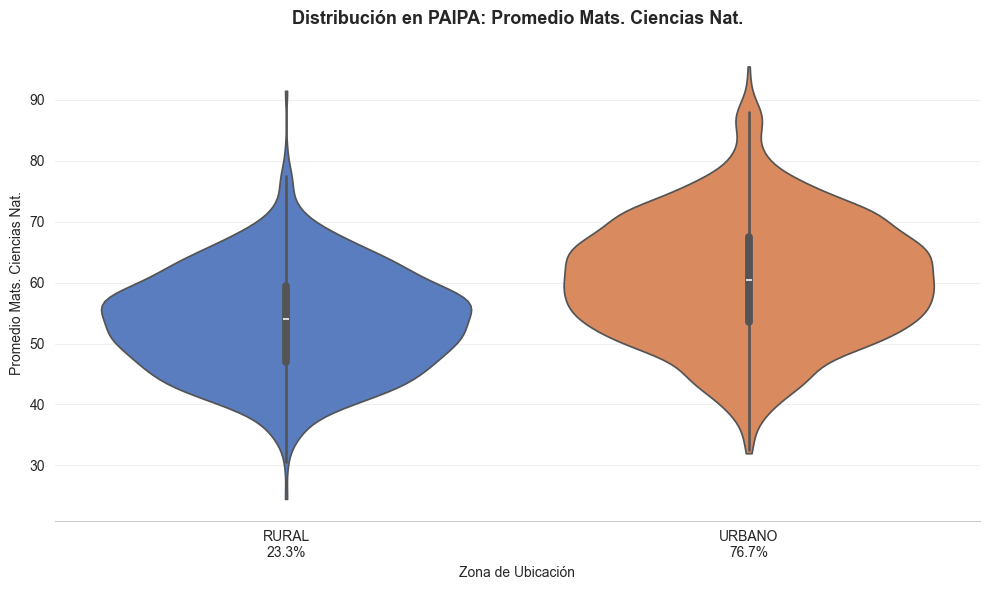

In [41]:
col_cat = 'cole_area_ubicacion'  
punt_col = 'punt_prom_mcn'
municipio = 'PAIPA'

map_cole_vars = {
    'cole_area_ubicacion': 'Zona de Ubicación',
    'cole_naturaleza': 'Naturaleza',
    'cole_caracter': 'Carácter',
    'cole_jornada': 'Jornada'
}
map_puntajes = {
    'punt_matematicas': 'Matemáticas',
    'punt_c_naturales': 'Ciencias Naturales',
    'punt_prom_mcn': 'Promedio Mats. Ciencias Nat.'
}

df_mun = Data_used[Data_used['cole_mcpio_ubicacion'] == municipio].copy()
df_mun = df_mun.dropna(subset=[col_cat, punt_col])

counts = df_mun[col_cat].value_counts(normalize=True) * 100
order = sorted(df_mun[col_cat].unique())
new_labels = [f"{cat}\n{counts[cat]:.1f}%" for cat in order]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '#f0f0f0'})


ax = sns.violinplot(data=df_mun, x=col_cat, y=punt_col, order=order, palette="muted", inner="box", cut=0)

plt.title(f"Distribución en {municipio}: {map_puntajes.get(punt_col, punt_col)}", fontsize=13, fontweight='bold', pad=15)
plt.ylabel(map_puntajes.get(punt_col, punt_col))
plt.xlabel(map_cole_vars.get(col_cat, col_cat))

ax.set_xticklabels(new_labels)

sns.despine(left=True)
plt.tight_layout()
plt.show()

### barras de variable colegio vs puntaje escogido para todoel depto

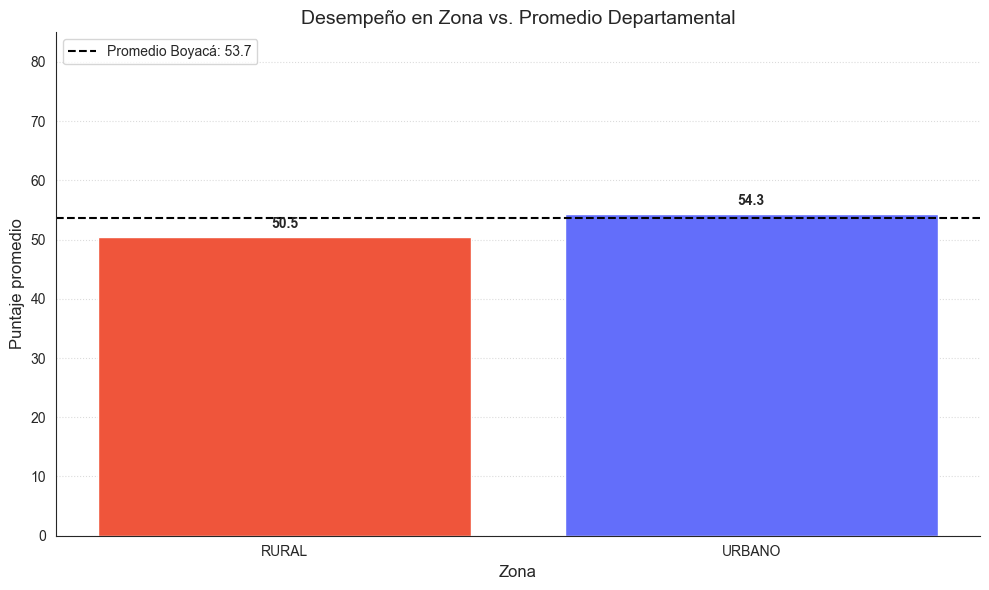

In [ ]:
var_col = 'cole_area_ubicacion'
punt_col = 'punt_prom_mcn'
map_vars = {
    'cole_area_ubicacion': 'Zona',
    'cole_naturaleza':     'Naturaleza',
    'cole_jornada':        'Jornada',
    'cole_caracter':       'Carácter'
}


df = Data_used.copy()
agg = df.groupby(var_col)[punt_col].agg(['mean', 'count']).reset_index()
agg.columns = [var_col, 'promedio', 'n']
agg = agg.sort_values('promedio')

promedio_dpto = df[punt_col].mean()


plt.figure(figsize=(10, 6))
sns.set_style("white")

colors = ['#EF553B' if v < promedio_dpto else '#636EFA' for v in agg['promedio']]

bars = plt.bar(agg[var_col], agg['promedio'], color=colors)


for bar, p, n in zip(bars, agg['promedio'], agg['n']):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 1, 
        # f'{p:.1f}\n(n={n})', 
        f'{p:.1f}', 
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.axhline(y=promedio_dpto, color='black', linestyle='--', linewidth=1.5, label=f'Promedio Boyacá: {promedio_dpto:.1f}')

plt.title(f'Desempeño en {map_vars.get(var_col, var_col)} vs. Promedio Departamental', fontsize=14)
plt.ylabel('Puntaje promedio', fontsize=12)
plt.xlabel(map_vars.get(var_col, var_col), fontsize=12)
plt.ylim(0, 85)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend(loc='upper left', frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

### tabla de municipios prioritarios 
Analisis, num de estudiantes.    
BRECHA: que tanto esta por debajo del promedio.    
IMPACTO POTENCIAL : brecha * cant estudiantes.   
% colegios rurales    
% cols oficiales 


In [ ]:
df = Data_used.copy()
df['mcpio_canon'] = df['cole_mcpio_ubicacion'].map(
    lambda x: mapa_norm_a_real.get(normalizar(x), x))
promedio_dpto = df[punt_col].mean()

agg = df.groupby('mcpio_canon').agg(
    promedio = (punt_col, 'mean'),
    n_estudiantes = (punt_col, 'count'),
    pct_rural = ('cole_area_ubicacion', lambda x: (x == 'RURAL').mean() * 100),
    pct_oficial = ('cole_naturaleza', lambda x: (x == 'OFICIAL').mean() * 100)
).reset_index()


agg['brecha'] = promedio_dpto - agg['promedio'] 
agg['impacto_potencial'] = agg['brecha'] * agg['n_estudiantes']  
agg = agg[agg['brecha'] > 0].sort_values('impacto_potencial', ascending=False)
agg[['mcpio_canon', 'promedio', 'n_estudiantes', 'pct_rural', 'pct_oficial', 'brecha', 'impacto_potencial']].head(14)

,mcpio_canon,promedio,n_estudiantes,pct_rural,pct_oficial,brecha,impacto_potencial
71,PUERTO BOYACA,47.387665,4856,25.967875,91.515651,6.294404,30565.625477
15,CHIQUINQUIRA,52.198692,8254,2.326145,73.697601,1.483377,12243.794828
76,SABOYA,49.211454,1362,100.000000,92.143906,4.470615,6088.977533
18,CHITA,47.257287,892,26.681614,100.000000,6.424782,5730.905256
60,OTANCHE,47.029162,823,17.496962,100.000000,6.652907,5475.342518
84,SAN PABLO DE BORBUR,47.030683,717,54.951185,100.000000,6.651385,4769.043239
54,MONIQUIRA,51.493899,1967,33.197763,93.950178,2.188169,4304.129080
1,AQUITANIA,50.390187,1284,21.417445,100.000000,3.291882,4226.776176
56,MUZO,49.026895,818,25.427873,100.000000,4.655174,3807.932175
66,PAUNA,49.192033,841,38.168847,100.000000,4.490035,3776.119754


### crear mapa

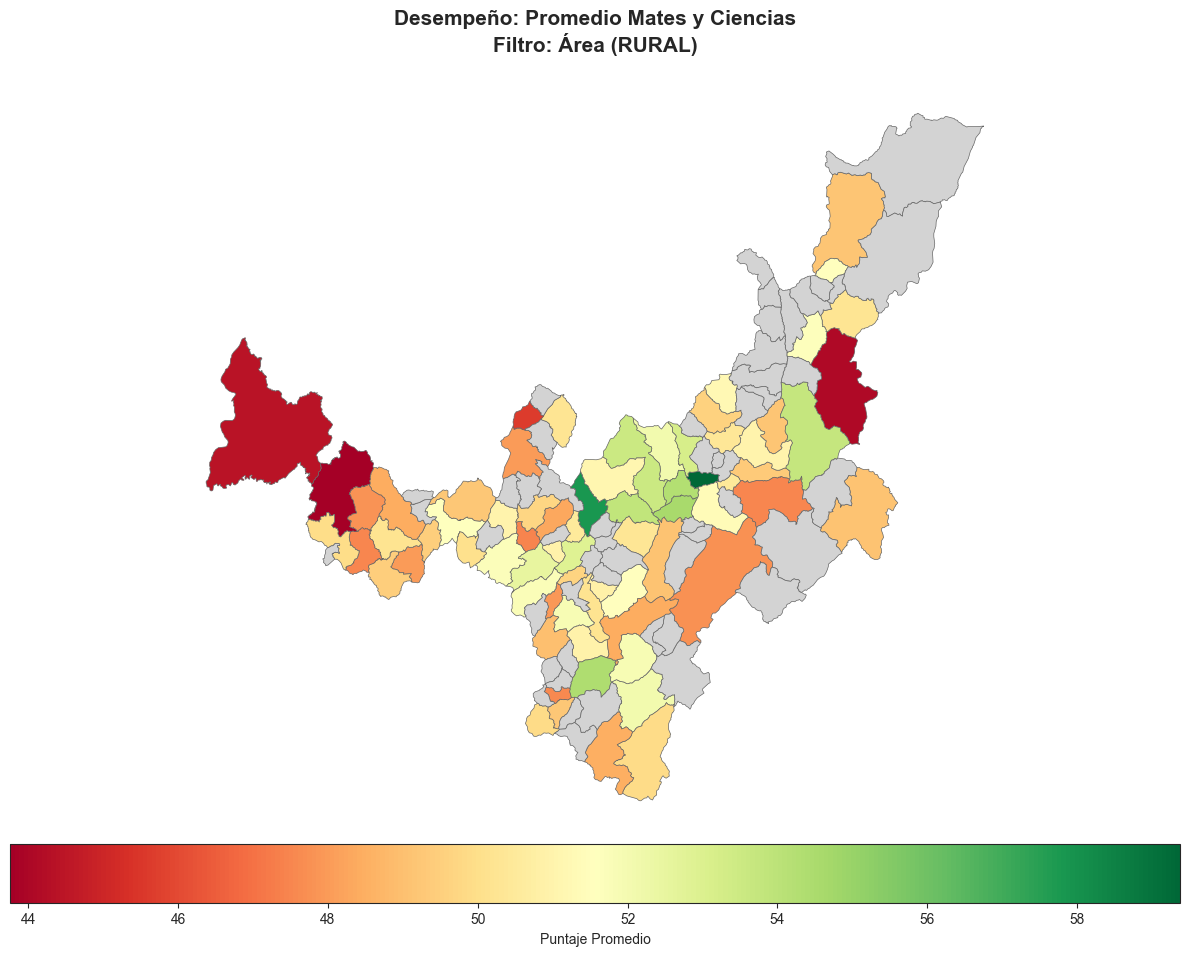

In [ ]:
def plot_mapa_boyaca(gdf_boyaca, df_stats, punt_label, cat_label="Sin filtro", cat_val="Todos"):        
    merged = gdf_boyaca.merge(df_stats, left_on='name_norm', right_on='mcpio_norm', how='left')
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.set_axis_off()
    
    titulo = f"Desempeño: {punt_label}\nFiltro: {cat_label} ({cat_val})"
    plt.title(titulo, fontsize=15, fontweight='bold', pad=20)
    
    merged.plot(
        column='promedio',
        cmap='RdYlGn', 
        linewidth=0.5,
        ax=ax,
        edgecolor='0.4',
        legend=True,
        missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'}, # Municipios sin datos
        legend_kwds={'label': "Puntaje Promedio", 'orientation': "horizontal", 'pad': 0.01}
    )

    plt.tight_layout()
    return fig

with open('../gadm41_COL_2.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)
    

def normalizar(name):
    name = name.lower().strip()
    name = unicodedata.normalize('NFKD', name)
    name = ''.join(c for c in name if not unicodedata.combining(c))
    name = name.replace(' ', '')
    name = name.replace('cienega', 'cienaga')
    name = name.replace('guicandelasierra', 'guican')
    name = name.replace('pisva', 'pisba')
    name = name.replace('tutasa', 'tutaza')
    return name

def preparar_geografia(geojson_data):
    gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])
    gdf['name_norm'] = gdf['NAME_2'].apply(normalizar) 
    return gdf

def agrup_municp(df, col_puntaje, col_cat=None, cat_valor=None):
    df = df.copy()
    df['cole_mcpio_ubicacion'] = df['cole_mcpio_ubicacion'].map(
        lambda x: mapa_norm_a_real.get(normalizar(x), x)
    )
    if col_cat and cat_valor:
        df = df[df[col_cat] == cat_valor]
    agg = df.groupby('cole_mcpio_ubicacion').agg(
        promedio = (col_puntaje, 'mean'),
        num_colegios = ('cole_nombre_establecimiento', 'nunique'),
        num_estudiantes = (col_puntaje, 'count')
    ).reset_index()
    agg['mcpio_norm'] = agg['cole_mcpio_ubicacion'].apply(normalizar)
    return agg

vars_cat = {
    'Sin filtro': None,
    'Área de Ubicación': 'cole_area_ubicacion',
    'Naturaleza': 'cole_naturaleza',           
    'Jornada': 'cole_jornada',                 
    'Carácter': 'cole_caracter'               
}

gdf_boyaca = preparar_geografia(filt_geojson)

col_cat_sel = vars_cat['Área de Ubicación']
df_resumen = agrup_municp(Data_used, 'punt_prom_mcn', col_cat_sel, 'RURAL')

fig = plot_mapa_boyaca(gdf_boyaca, df_resumen, "Promedio Mates y Ciencias", "Área", "RURAL")
plt.show()